# COVID-19 Patient Symptoms & Diagnosis Analysis

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
data = pd.read_csv('datasets/covid19_patient_symptoms_diagnosis.csv', index_col='patient_id')
data

,age,gender,fever,dry_cough,sore_throat,fatigue,headache,shortness_of_breath,loss_of_smell,loss_of_taste,oxygen_level,body_temperature,comorbidity,travel_history,contact_with_patient,chest_pain,covid_result
patient_id,,,,,,,,,,,,,,,,,
1,52,Male,1,0,1,1,0,0,0,0,98,37.1,Diabetes,0,0,0,0
2,15,Male,0,0,0,1,1,0,0,0,85,37.7,Diabetes,0,1,0,0
3,72,Male,1,0,1,0,0,1,0,1,99,36.8,NaN,0,0,0,0
4,61,Female,0,0,1,1,1,0,1,1,86,36.0,NaN,1,0,0,0
5,21,Female,1,1,0,0,0,1,0,1,90,36.4,NaN,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,89,Female,0,1,1,0,0,0,0,1,94,37.0,NaN,0,1,0,0
4997,62,Male,1,1,0,0,0,0,0,0,86,40.0,NaN,0,0,0,1
4998,13,Female,0,1,1,1,0,1,0,0,89,41.0,Diabetes,1,0,0,1


In [56]:
data.isnull().sum()

age                        0
gender                     0
fever                      0
dry_cough                  0
sore_throat                0
fatigue                    0
headache                   0
shortness_of_breath        0
loss_of_smell              0
loss_of_taste              0
oxygen_level               0
body_temperature           0
comorbidity             2725
travel_history             0
contact_with_patient       0
chest_pain                 0
covid_result               0
dtype: int64

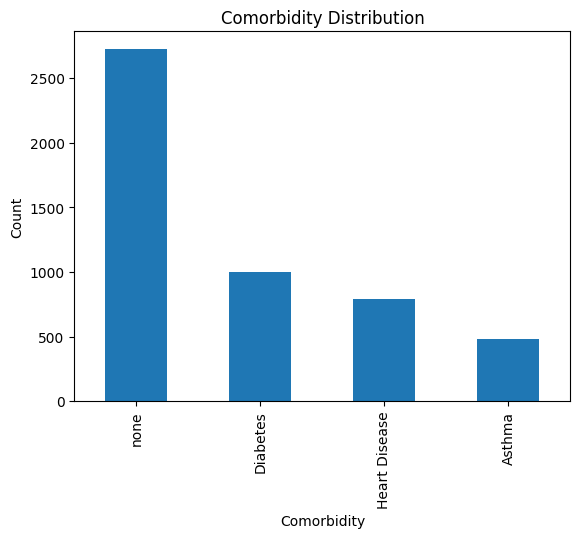

In [57]:
a = data["comorbidity"]
a = a.fillna("none")
# a.value_counts()
a.value_counts().plot(kind="bar")
plt.title("Comorbidity Distribution")
plt.xlabel("Comorbidity")
plt.ylabel("Count")
plt.show()

C:\Users\sahor\AppData\Local\Temp\ipykernel_19440\3522682874.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=a, palette="Set2")


<Axes: xlabel='comorbidity', ylabel='count'>

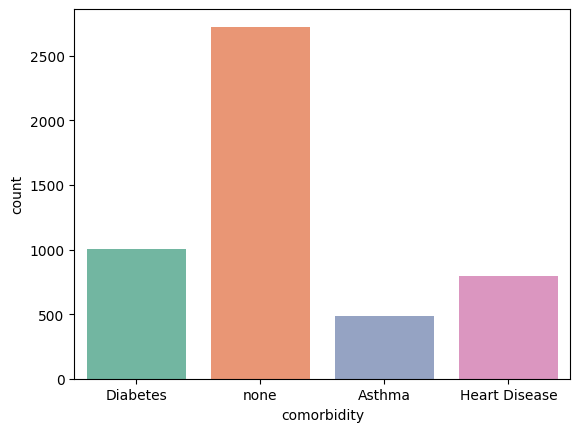

In [58]:
sns.countplot(x=a, palette="Set2")

C:\Users\sahor\AppData\Local\Temp\ipykernel_19440\1562104246.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='comorbidity', data=data, palette="Set2")


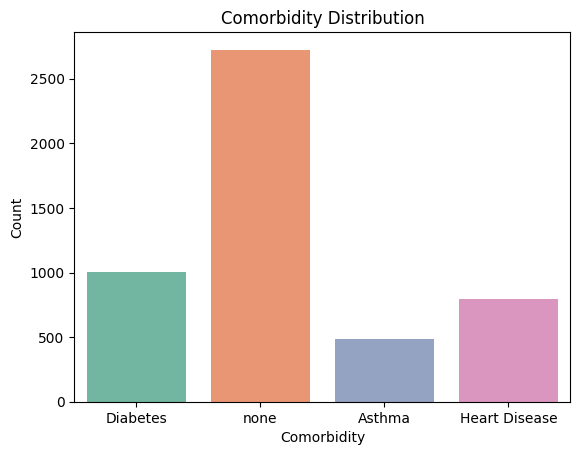

In [59]:
data["comorbidity"] = data["comorbidity"].fillna("none")
sns.countplot(x='comorbidity', data=data, palette="Set2")
plt.title("Comorbidity Distribution")
plt.xlabel("Comorbidity")
plt.ylabel("Count")
plt.show()

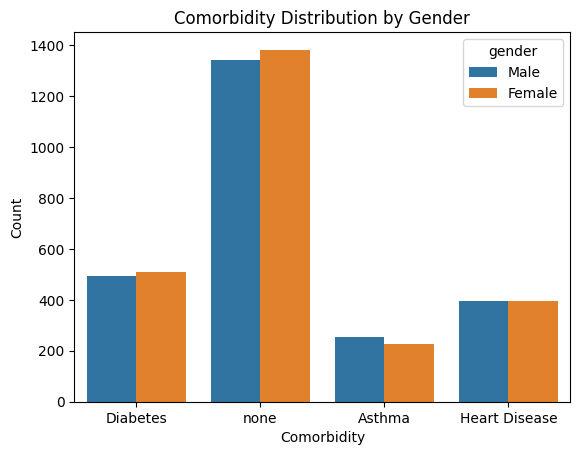

In [60]:
sns.countplot(x='comorbidity',hue='gender', data=data)
plt.title("Comorbidity Distribution by Gender")
plt.xlabel("Comorbidity")
plt.ylabel("Count")
plt.show()

In [61]:
data.head(3)

,age,gender,fever,dry_cough,sore_throat,fatigue,headache,shortness_of_breath,loss_of_smell,loss_of_taste,oxygen_level,body_temperature,comorbidity,travel_history,contact_with_patient,chest_pain,covid_result
patient_id,,,,,,,,,,,,,,,,,
1,52,Male,1,0,1,1,0,0,0,0,98,37.1,Diabetes,0,0,0,0
2,15,Male,0,0,0,1,1,0,0,0,85,37.7,Diabetes,0,1,0,0
3,72,Male,1,0,1,0,0,1,0,1,99,36.8,none,0,0,0,0


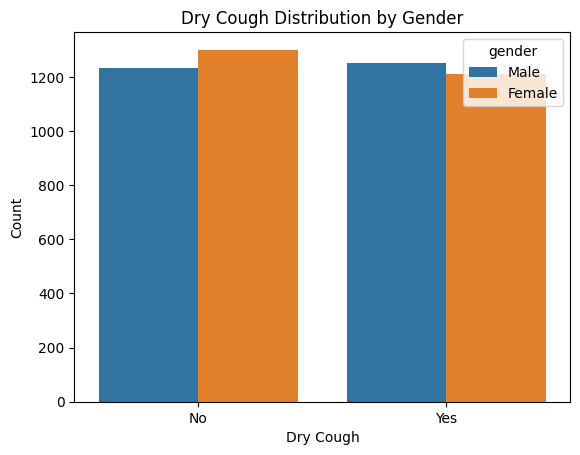

In [62]:
sns.countplot(x="dry_cough", hue="gender", data=data)
plt.title("Dry Cough Distribution by Gender")
plt.xlabel("Dry Cough")
plt.ylabel("Count")
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

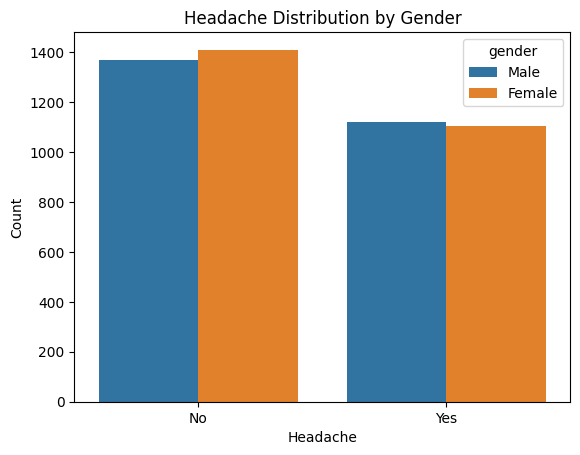

In [63]:
sns.countplot(x='headache', hue='gender', data=data)
plt.title("Headache Distribution by Gender")
plt.xlabel("Headache")
plt.ylabel("Count")
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

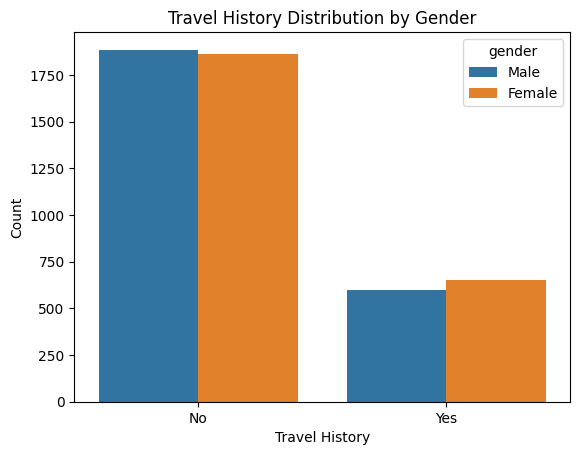

In [64]:
sns.countplot(x="travel_history", hue="gender", data=data)
plt.title("Travel History Distribution by Gender")
plt.xlabel("Travel History")
plt.ylabel("Count")
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

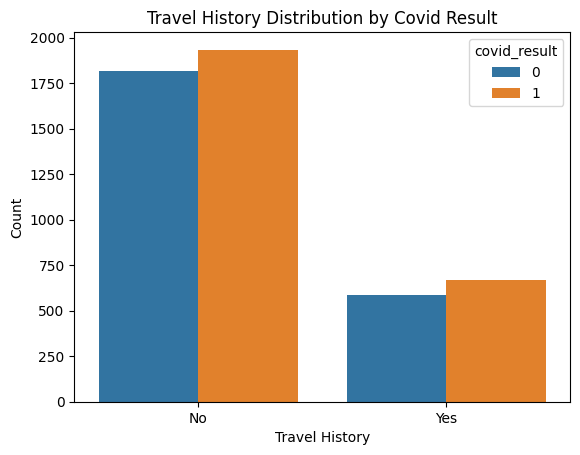

In [65]:
sns.countplot(x="travel_history", hue="covid_result", data=data)
plt.title("Travel History Distribution by Covid Result")
plt.xlabel("Travel History")
plt.ylabel("Count")
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

In [66]:
data.head(2)

,age,gender,fever,dry_cough,sore_throat,fatigue,headache,shortness_of_breath,loss_of_smell,loss_of_taste,oxygen_level,body_temperature,comorbidity,travel_history,contact_with_patient,chest_pain,covid_result
patient_id,,,,,,,,,,,,,,,,,
1,52,Male,1,0,1,1,0,0,0,0,98,37.1,Diabetes,0,0,0,0
2,15,Male,0,0,0,1,1,0,0,0,85,37.7,Diabetes,0,1,0,0


In [67]:
data["gender"].value_counts()

gender
Female    2514
Male      2486
Name: count, dtype: int64

In [68]:
data["covid_result"].value_counts()

covid_result
1    2600
0    2400
Name: count, dtype: int64

In [69]:
from sklearn.preprocessing import LabelEncoder
l_coder = LabelEncoder()
data["gender"] = l_coder.fit_transform(data["gender"])
data["comorbidity"] = l_coder.fit_transform(data["comorbidity"])

In [70]:
data["gender"]

patient_id
1       1
2       1
3       1
4       0
5       0
       ..
4996    0
4997    1
4998    0
4999    0
5000    1
Name: gender, Length: 5000, dtype: int64

In [71]:
from sklearn.model_selection import train_test_split

In [72]:
x = data.drop("covid_result", axis=1)
y = data["covid_result"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [73]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()

In [74]:
x_test

,age,gender,fever,dry_cough,sore_throat,fatigue,headache,shortness_of_breath,loss_of_smell,loss_of_taste,oxygen_level,body_temperature,comorbidity,travel_history,contact_with_patient,chest_pain
patient_id,,,,,,,,,,,,,,,,
1502,49,1,0,0,0,1,1,0,1,1,98,39.0,2,0,0,0
2587,29,1,1,0,1,0,1,0,1,0,88,36.4,3,0,0,1
2654,85,1,1,0,1,1,0,0,0,1,87,37.2,2,1,0,0
1056,2,1,1,0,0,0,1,0,1,1,92,38.6,3,0,0,1
706,69,1,1,0,0,0,0,0,0,1,95,36.2,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3564,27,0,0,1,1,1,0,1,0,1,97,39.8,0,1,1,0
1539,5,1,1,0,1,0,0,0,0,0,97,39.4,3,0,1,0
1838,74,1,1,1,1,1,0,1,1,0,93,40.5,2,0,0,0


In [75]:
log_model.fit(x_train, y_train)

C:\Users\sahor\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [76]:
log_model.score(x_test, y_test)

0.9593333333333334

In [77]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier()
dt_model.fit(x_train, y_train)
dt_model.score(x_test, y_test)

1.0

In [78]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(x_train, y_train)
rf_model.score(x_test, y_test)

1.0

In [79]:
from sklearn.svm import SVC
svc_model = SVC()
svc_model.fit(x_train, y_train)
svc_model.score(x_test, y_test)

0.674

In [80]:
data.corr()

,age,gender,fever,dry_cough,sore_throat,fatigue,headache,shortness_of_breath,loss_of_smell,loss_of_taste,oxygen_level,body_temperature,comorbidity,travel_history,contact_with_patient,chest_pain,covid_result
age,1.000000,-0.010148,-0.013158,0.012110,-0.009921,-0.000579,0.010169,-0.006161,-0.011789,-0.004545,-0.000482,-0.026185,0.005889,0.002007,0.004327,-0.023481,0.008515
gender,-0.010148,1.000000,0.006817,0.021526,0.016088,0.020133,0.010647,-0.010177,0.029426,0.012394,-0.004318,-0.026232,-0.014014,-0.021222,-0.006042,0.002851,0.010633
fever,-0.013158,0.006817,1.000000,0.005484,0.001481,0.004709,-0.012102,0.001346,-0.013572,0.016258,-0.007729,-0.003514,0.002215,0.014949,0.000989,-0.008867,0.327860
dry_cough,0.012110,0.021526,0.005484,1.000000,0.010668,-0.000363,0.011369,-0.009365,0.005834,-0.004435,0.033517,0.000647,0.011087,-0.001827,-0.013392,-0.007462,0.346453
sore_throat,-0.009921,0.016088,0.001481,0.010668,1.000000,0.016677,-0.023013,-0.025269,-0.030789,-0.023206,-0.018698,0.016636,-0.022423,-0.016150,0.008283,0.004860,-0.005360
fatigue,-0.000579,0.020133,0.004709,-0.000363,0.016677,1.000000,0.005961,0.011579,0.019593,0.004944,0.000666,0.003318,-0.024435,-0.015031,-0.007138,0.025240,0.007748
headache,0.010169,0.010647,-0.012102,0.011369,-0.023013,0.005961,1.000000,0.004357,0.008027,0.015754,-0.002215,-0.019640,-0.018373,0.017335,0.039761,-0.014449,0.010891
shortness_of_breath,-0.006161,-0.010177,0.001346,-0.009365,-0.025269,0.011579,0.004357,1.000000,0.019655,0.015629,0.016949,0.002657,-0.002307,0.006252,-0.010967,-0.009156,0.318567
loss_of_smell,-0.011789,0.029426,-0.013572,0.005834,-0.030789,0.019593,0.008027,0.019655,1.000000,-0.008945,-0.019854,-0.005740,-0.003960,-0.006195,0.012658,0.020770,0.329140
loss_of_taste,-0.004545,0.012394,0.016258,-0.004435,-0.023206,0.004944,0.015754,0.015629,-0.008945,1.000000,0.008722,0.019646,0.016066,0.013308,0.019199,0.014321,0.011190
